# Live 3D Hand Localization
This notebook connects to 3 webcams (indices 0, 1, and 2), detects hands in real-time using YOLOv8, and triangulates the 3D position.

In [2]:
import sys
import os
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

# Add project root to path
sys.path.append(os.path.abspath('..'))
from scripts.localization.localize_hand import HandLocalizer

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\adith\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [1]:
from cv2_enumerate_cameras import enumerate_cameras

for camera in enumerate_cameras():
    print(f"Index: {camera.index}, Name: {camera.name}, Path: {camera.path}")

Index: 1400, Name: ACER FHD User Facing, Path: \\?\usb#vid_04f2&pid_b799&mi_00#6&720634e&0&0000#{e5323777-f976-4f5b-9b55-b94699c46e44}\global
Index: 1401, Name: HD Pro Webcam C920, Path: \\?\usb#vid_046d&pid_0892&mi_00#7&88b8624&0&0000#{e5323777-f976-4f5b-9b55-b94699c46e44}\global
Index: 1402, Name: HD Pro Webcam C920, Path: \\?\usb#vid_046d&pid_0892&mi_00#6&33180f3c&0&0000#{e5323777-f976-4f5b-9b55-b94699c46e44}\global
Index: 1403, Name: HD Pro Webcam C920, Path: \\?\usb#vid_046d&pid_0892&mi_00#6&30c64aa1&0&0000#{e5323777-f976-4f5b-9b55-b94699c46e44}\global
Index: 700, Name: ACER FHD User Facing, Path: \\?\usb#vid_04f2&pid_b799&mi_00#6&720634e&0&0000#{65e8773d-8f56-11d0-a3b9-00a0c9223196}\global
Index: 701, Name: HD Pro Webcam C920, Path: \\?\usb#vid_046d&pid_0892&mi_00#7&88b8624&0&0000#{65e8773d-8f56-11d0-a3b9-00a0c9223196}\global
Index: 702, Name: HD Pro Webcam C920, Path: \\?\usb#vid_046d&pid_0892&mi_00#6&33180f3c&0&0000#{65e8773d-8f56-11d0-a3b9-00a0c9223196}\global
Index: 703, Name

Fine-tuned model not found at ../models/hand_detector/weights/best.pt. Falling back to default yolov8n.pt
Camera 701 initialized at 640x480 (MJPEG).
Camera 701 test frame captured successfully.


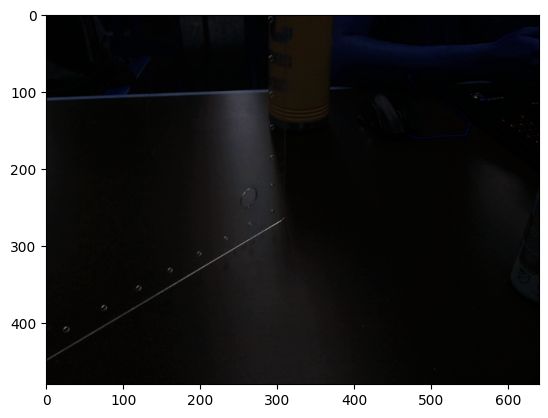

Camera 702 initialized at 640x480 (MJPEG).
Camera 702 test frame captured successfully.


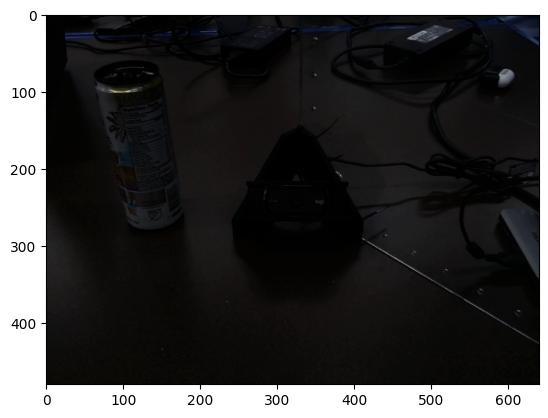

Camera 703 initialized at 640x480 (MJPEG).
Camera 703 test frame captured successfully.


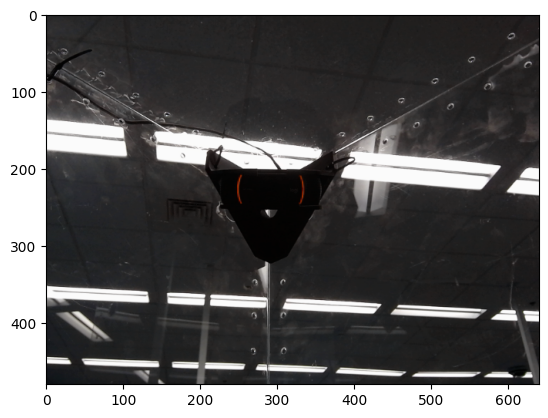

In [5]:
# 1. Initialize Pipeline
config_path = '../configs/camera_params.yaml'

# Look for fine-tuned model, otherwise fallback to the base YOLO model
model_path = '../models/hand_detector/weights/best.pt'
if not os.path.exists(model_path):
    print(f"Fine-tuned model not found at {model_path}. Falling back to default yolov8n.pt")
    model_path = 'yolov8n.pt'

localizer = HandLocalizer(config_path, model_path)

# 2. Initialize Webcams
# If 1400 range (MSMF) is flaky, try the 700 range (DirectShow): [700, 703, 704]
cam_indices = [701, 702, 703] 
cams = []

for idx in cam_indices:
    cap = cv2.VideoCapture(idx)
    if cap.isOpened():
        # CRITICAL FOR MULTI-CAM: Force MJPEG compression to save USB bandwidth
        cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*'MJPG'))
        # Lower resolution to further save bandwidth
        cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
        cap.set(cv2.CAP_PROP_FPS, 30)
        cams.append(cap)
        print(f'Camera {idx} initialized at 640x480 (MJPEG).')
        ret, frame = cap.read()
        if (ret):
            print(f"Camera {idx} test frame captured successfully.")
            plt.imshow(frame)
            plt.show()
        else:
            print(f"Warning: Failed to capture test frame from camera {idx}")
            if frame:
                print(f"Frame exists however:")
                plt.imshow(frame)
                plt.show()
    else:
        print(f"Warning: Failed to open camera {idx}")

In [ ]:
# 3. Live 3D Plotting Loop
%matplotlib inline
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

cam_names = ['cam1', 'cam2', 'cam3']
cam_positions = [localizer.config['cameras'][cam_id]['position'] for cam_id in cam_names]

try:
    # Run for 200 frames. 
    for frame_idx in range(200):
        frames = []
        failed_cam_names = []
        
        # Grab frames from all cameras
        for i, cam in enumerate(cams):
            ret, frame = cam.read()
            if ret:
                frames.append(frame)
            else:
                frames.append(None)
                failed_cam_names.append(cam_names[i])
                
        # --- Update 3D Plot ---
        ax.cla() # Clear previous points
        
        # Draw Cameras (Red if failed, Blue if active)
        for name, pos in zip(cam_names, cam_positions):
            color = 'red' if name in failed_cam_names else 'blue'
            ax.scatter(*pos, c=color, marker='s', s=100)
            ax.text(pos[0], pos[1], pos[2] + 15, name, color=color, fontweight='bold')
            
        # Draw Origin
        ax.scatter(0, 0, 0, c='black', marker='x', s=100, label='Origin [0,0,0]')

        estimated_3d_pos = None
        if failed_cam_names:
            error_msg = f"Missing frames from: {', '.join(failed_cam_names)}"
            ax.text2D(0.05, 0.95, error_msg, transform=ax.transAxes, color='red', fontsize=12, fontweight='bold')
        else:
            # Triangulate Hand Position
            estimated_3d_pos = localizer.localize_3d(frames)
            
            # Show 2D previews
            preview = cv2.hconcat([cv2.resize(f, (320, 240)) for f in frames])
            cv2.imshow("Camera Feeds", preview)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                print("User exited.")
                break

        # Draw Hand
        if estimated_3d_pos is not None:
            ax.scatter(*estimated_3d_pos, c='red', marker='*', s=300, label='Hand')
            for pos in cam_positions:
                ax.plot([pos[0], estimated_3d_pos[0]], 
                        [pos[1], estimated_3d_pos[1]], 
                        [pos[2], estimated_3d_pos[2]], 'g--', alpha=0.5)
        elif not failed_cam_names:
            ax.text2D(0.05, 0.95, "No hand detected", transform=ax.transAxes, color='orange', fontsize=12)

        # Fix axis limits
        ax.set_xlim([-200, 200])
        ax.set_ylim([-200, 200])
        ax.set_zlim([-150, 150])
        ax.set_xlabel('X (mm)')
        ax.set_ylabel('Y (mm)')
        ax.set_zlabel('Z (mm)')
        ax.set_title(f'Live 3D Hand Localization (Frame {frame_idx})')
        ax.legend(loc='upper right')

        clear_output(wait=True)
        display(fig)
        
except KeyboardInterrupt:
    print("\nStopped by user.")
finally:
    # CRITICAL CLEANUP
    for cam in cams:
        if cam is not None:
            cam.release()
    cv2.destroyAllWindows()
    print("Hardware released.")